# Conformal Prediction for Directed Graph Link Prediction - WikiLinks Dataset

This notebook applies the directed link prediction framework with conformal prediction to the **WikiLinks** dataset loaded via `load_netset` from scikit-network.

## Dataset Information
- **Source**: https://netset.telecom-paris.fr/pages/wikilinks.html
- **Nodes**: ~3.2M Wikipedia articles
- **Edges**: ~67M directed hyperlinks
- **Note**: Due to the large size, we use sampling strategies for tractable computation

In [10]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sknetwork.data import load_netset
from sknetwork.embedding import SVD
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_fscore_support

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

print("Imports loaded successfully.")

Imports loaded successfully.


## 1. Load WikiLinks Dataset using load_netset

In [11]:
# Load the WikiLinks dataset
# This may take some time due to the large size
print("Loading WikiLinks dataset from NetSet...")
print("(This may take a few minutes for the first download)")

dataset = load_netset('wikilinks')

print(f"\nDataset loaded successfully!")
print(f"Keys available: {list(dataset.keys())}")

Loading WikiLinks dataset from NetSet...
(This may take a few minutes for the first download)
Parsing files...
Done.

Dataset loaded successfully!
Keys available: ['adjacency', 'biadjacency', 'meta', 'names', 'names_col', 'wikidata_ids']


In [12]:
# Extract the adjacency matrix
adj_full = dataset['adjacency']

print(f"Full adjacency matrix shape: {adj_full.shape}")
print(f"Number of edges: {adj_full.nnz:,}")
print(f"Density: {adj_full.nnz / (adj_full.shape[0] * adj_full.shape[1]):.6f}")

# Check if names are available
if 'names' in dataset:
    names = dataset['names']
    print(f"\nSample node names: {names[:5]}")

Full adjacency matrix shape: (3210346, 3210346)
Number of edges: 67,196,296
Density: 0.000007

Sample node names: ['! (disambiguation)' '!!' '!!!' '!!! (album)' '!Action Pact!']


## 2. Subgraph Sampling for Tractable Computation

Due to the large size of WikiLinks (~3.2M nodes), we extract a connected subgraph for efficient experimentation.

In [13]:
def extract_largest_subgraph(adj, max_nodes=50000, seed=42):
    """
    Extract a subgraph by starting from high-degree nodes and expanding via BFS.
    
    Parameters:
    -----------
    adj : sparse matrix
        Full adjacency matrix
    max_nodes : int
        Maximum number of nodes to include
    seed : int
        Random seed for reproducibility
    
    Returns:
    --------
    adj_sub : sparse matrix
        Subgraph adjacency matrix
    node_indices : array
        Indices of selected nodes in original graph
    """
    rng = np.random.default_rng(seed)
    n_nodes = adj.shape[0]
    
    # Compute total degree (in + out)
    out_deg = np.array(adj.sum(axis=1)).flatten()
    in_deg = np.array(adj.sum(axis=0)).flatten()
    total_deg = out_deg + in_deg
    
    # Start from top-degree nodes
    top_nodes = np.argsort(total_deg)[-100:]  # Top 100 by degree
    start_node = rng.choice(top_nodes)
    
    # BFS expansion
    visited = set([start_node])
    queue = [start_node]
    
    # Make adj symmetric for BFS (consider both directions)
    adj_sym = adj + adj.T
    
    while len(visited) < max_nodes and queue:
        node = queue.pop(0)
        neighbors = adj_sym[node].indices
        
        for neighbor in neighbors:
            if neighbor not in visited and len(visited) < max_nodes:
                visited.add(neighbor)
                queue.append(neighbor)
    
    node_indices = np.array(sorted(visited))
    
    # Extract subgraph
    adj_sub = adj[node_indices][:, node_indices]
    
    return adj_sub, node_indices

print("Subgraph extraction function ready.")

Subgraph extraction function ready.


In [14]:
# Extract subgraph (adjust max_nodes based on your memory constraints)
MAX_NODES = 30000  # Adjust this based on available memory

print(f"Extracting subgraph with up to {MAX_NODES:,} nodes...")
adj, node_indices = extract_largest_subgraph(adj_full, max_nodes=MAX_NODES, seed=RNG_SEED)

# Remove self-loops and ensure proper format
adj.setdiag(0)
adj.eliminate_zeros()
adj = adj.tocsr()

n_nodes = adj.shape[0]
n_edges = adj.nnz

print(f"\nSubgraph extracted:")
print(f"  Nodes: {n_nodes:,}")
print(f"  Edges: {n_edges:,}")
print(f"  Avg degree: {n_edges / n_nodes:.2f}")

# Get node names if available
if 'names' in dataset:
    subgraph_names = dataset['names'][node_indices]
    print(f"\nSample nodes in subgraph: {list(subgraph_names[:5])}")

Extracting subgraph with up to 30,000 nodes...

Subgraph extracted:
  Nodes: 30,000
  Edges: 831,329
  Avg degree: 27.71

Sample nodes in subgraph: [np.str_('!Women Art Revolution'), np.str_("$100 Bill Y'all"), np.str_("'A' You're Adorable"), np.str_("'Fore She Was Mama"), np.str_("'Merican")]


## 3. Core Functions for Directed Link Prediction

In [15]:
def conformal_quantile(scores, alpha):
    """
    Mondrian (label-conditional) split conformal quantile.
    Returns the k-th order statistic where k = ceil((n+1)(1-alpha)).
    """
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    
    if k > n:
        return np.inf
    
    sorted_scores = np.sort(scores)
    return sorted_scores[k - 1]


def get_directed_node_features(adj, n_components=32):
    """
    Extract node features for directed graphs using SVD embeddings.
    """
    out_degrees = np.array(adj.sum(axis=1)).flatten()
    in_degrees = np.array(adj.sum(axis=0)).flatten()
    
    print(f"Computing SVD Embeddings (Rank {n_components})...")
    svd = SVD(n_components=n_components)
    source_embedding = svd.fit_transform(adj)
    target_embedding = svd.embedding_col_
    
    return out_degrees, in_degrees, source_embedding, target_embedding


def compute_directed_pair_features(pairs, out_degrees, in_degrees, source_emb, target_emb):
    """
    Compute features for directed edge pairs (u -> v).
    Features: [out_deg_u, in_deg_v, in_deg_u, out_deg_v, sim_forward, sim_reverse]
    """
    u = pairs[:, 0]
    v = pairs[:, 1]
    
    out_deg_u = out_degrees[u]
    in_deg_v = in_degrees[v]
    in_deg_u = in_degrees[u]
    out_deg_v = out_degrees[v]
    
    # Forward similarity: u_source . v_target
    vec_u_source = source_emb[u]
    vec_v_target = target_emb[v]
    
    norm_u_source = np.linalg.norm(vec_u_source, axis=1)
    norm_v_target = np.linalg.norm(vec_v_target, axis=1)
    norm_u_source[norm_u_source == 0] = 1e-9
    norm_v_target[norm_v_target == 0] = 1e-9
    
    dot_forward = np.sum(vec_u_source * vec_v_target, axis=1)
    sim_forward = dot_forward / (norm_u_source * norm_v_target)
    
    # Reverse similarity: v_source . u_target
    vec_v_source = source_emb[v]
    vec_u_target = target_emb[u]
    
    norm_v_source = np.linalg.norm(vec_v_source, axis=1)
    norm_u_target = np.linalg.norm(vec_u_target, axis=1)
    norm_v_source[norm_v_source == 0] = 1e-9
    norm_u_target[norm_u_target == 0] = 1e-9
    
    dot_reverse = np.sum(vec_v_source * vec_u_target, axis=1)
    sim_reverse = dot_reverse / (norm_v_source * norm_u_target)
    
    return np.column_stack([out_deg_u, in_deg_v, in_deg_u, out_deg_v, sim_forward, sim_reverse])

print("Core functions ready.")

Core functions ready.


## 4. Directed Pipeline with Feature Importance and Error Analysis

In [16]:
FEATURE_NAMES_DIRECTED = ['out_deg_u', 'in_deg_v', 'in_deg_u', 'out_deg_v', 'sim_forward', 'sim_reverse']

def run_directed_pipeline(adj, name="dataset", alpha=0.10, n_runs=5, n_components=32, msg_ratio=0.7, node_names=None):
    """
    OGB-style directed link prediction with conformal prediction, feature importance, and error analysis.
    """
    print(f"\n{'='*60}")
    print(f"Running Directed Graph Pipeline: {name.upper()}")
    print(f"Averaging over {n_runs} runs")
    print(f"Message/Supervision split: {msg_ratio:.0%} / {1-msg_ratio:.0%}")
    print(f"{'='*60}")
    
    n_nodes = adj.shape[0]
    print(f"Graph: {n_nodes:,} nodes, {adj.nnz:,} edges")
    
    # Get all directed edges
    rows, cols = adj.nonzero()
    all_edges = np.column_stack([rows, cols])
    all_edges_set = set(zip(rows, cols))
    print(f"Total directed edges: {len(all_edges):,}")
    
    run_results = []
    last_run_data = {}
    
    for seed in range(n_runs):
        rng = np.random.default_rng(seed)
        
        edges = all_edges.copy()
        rng.shuffle(edges)
        
        n = len(edges)
        n_cal = int(n * 0.1)
        n_test = int(n * 0.1)
        
        E_cal = edges[:n_cal]
        E_test = edges[n_cal:n_cal + n_test]
        E_train_all = edges[n_cal + n_test:]
        
        n_train = len(E_train_all)
        n_msg = int(n_train * msg_ratio)
        
        train_idx = rng.permutation(n_train)
        E_msg = E_train_all[train_idx[:n_msg]]
        E_sup = E_train_all[train_idx[n_msg:]]
        
        # Build message graph
        msg_data = np.ones(len(E_msg))
        adj_msg = sp.csr_matrix((msg_data, (E_msg[:, 0], E_msg[:, 1])), shape=(n_nodes, n_nodes))
        adj_msg.data = np.ones_like(adj_msg.data)
        adj_msg.setdiag(0)
        adj_msg.eliminate_zeros()
        
        out_deg, in_deg, src_emb, tgt_emb = get_directed_node_features(adj_msg, n_components)
        
        def make_dataset(pos_edges):
            neg_edges = set()
            n_needed = len(pos_edges)
            
            while len(neg_edges) < n_needed:
                u, v = rng.integers(0, n_nodes, 2)
                if u != v and (u, v) not in all_edges_set:
                    neg_edges.add((u, v))
            
            neg_edges = np.array(list(neg_edges))
            
            X_pos = compute_directed_pair_features(pos_edges, out_deg, in_deg, src_emb, tgt_emb)
            X_neg = compute_directed_pair_features(neg_edges, out_deg, in_deg, src_emb, tgt_emb)
            
            X = np.vstack([X_pos, X_neg])
            y = np.hstack([np.ones(len(pos_edges)), np.zeros(len(neg_edges))])
            all_pairs = np.vstack([pos_edges, neg_edges])
            
            return X, y, all_pairs
        
        X_train, y_train, _ = make_dataset(E_sup)
        X_cal, y_cal, _ = make_dataset(E_cal)
        X_test, y_test, test_pairs = make_dataset(E_test)
        
        clf = GradientBoostingClassifier(random_state=seed, n_estimators=100)
        clf.fit(X_train, y_train)
        
        p_cal = clf.predict_proba(X_cal)[:, 1]
        p_test = clf.predict_proba(X_test)[:, 1]
        
        scores_pos = 1 - p_cal[y_cal == 1]
        scores_neg = p_cal[y_cal == 0]
        
        q1 = conformal_quantile(scores_pos, alpha)
        q0 = conformal_quantile(scores_neg, alpha)
        
        t_lower = q0
        t_upper = 1 - q1
        
        sets = []
        for p in p_test:
            s = set()
            if p <= t_lower:
                s.add(0)
            if p >= t_upper:
                s.add(1)
            if len(s) == 0:
                s = {0, 1}
            sets.append(s)
        
        coverage = np.mean([y in s for y, s in zip(y_test, sets)])
        abstention = np.mean([len(s) > 1 for s in sets])
        
        decided_idx = [i for i, s in enumerate(sets) if len(s) == 1]
        if decided_idx:
            y_dec = y_test[decided_idx]
            p_dec = [list(sets[i])[0] for i in decided_idx]
            _, _, f1_dec, _ = precision_recall_fscore_support(y_dec, p_dec, average='binary', zero_division=0)
        else:
            f1_dec = 0.0
        
        auc = roc_auc_score(y_test, p_test)
        y_pred_std = (p_test >= 0.5).astype(int)
        _, _, base_f1, _ = precision_recall_fscore_support(y_test, y_pred_std, average='binary', zero_division=0)
        
        run_results.append({
            "AUC": auc,
            "Base F1": base_f1,
            "Coverage": coverage,
            "Abstention": abstention,
            "Decided F1": f1_dec
        })
        
        last_run_data = {
            'clf': clf,
            'y_test': y_test,
            'p_test': p_test,
            'y_pred_std': y_pred_std,
            'X_test': X_test,
            'test_pairs': test_pairs,
            't_lower': t_lower,
            't_upper': t_upper,
            'sets': sets,
            'auc': auc
        }
        
        print(f"Run {seed+1}/{n_runs}: AUC={auc:.4f} | Cov={coverage:.4f} | Abs={abstention:.4f}")
    
    # Aggregate results
    df = pd.DataFrame(run_results)
    means = df.mean()
    stds = df.std()
    
    print(f"\n{'='*60}")
    print(f"FINAL RESULTS ({name.upper()})")
    print(f"{'='*60}")
    print(f"Splits: E_msg={n_msg:,}, E_sup={n_train-n_msg:,}, E_cal={n_cal:,}, E_test={n_test:,}")
    for col in df.columns:
        print(f"{col:15s}: {means[col]:.4f} +/- {stds[col]:.4f}")
    
    # ==========================================
    # FEATURE IMPORTANCE ANALYSIS
    # ==========================================
    print(f"\n{'='*60}")
    print(f"FEATURE IMPORTANCE (Last Run)")
    print(f"{'='*60}")
    
    clf = last_run_data['clf']
    feature_importance = clf.feature_importances_
    sorted_idx = np.argsort(feature_importance)[::-1]
    
    for i, idx in enumerate(sorted_idx):
        print(f"{i+1}. {FEATURE_NAMES_DIRECTED[idx]}: {feature_importance[idx]:.4f}")
    
    # ==========================================
    # ERROR ANALYSIS
    # ==========================================
    print(f"\n{'='*60}")
    print(f"ERROR ANALYSIS (Last Run)")
    print(f"{'='*60}")
    
    y_test = last_run_data['y_test']
    p_test = last_run_data['p_test']
    y_pred_std = last_run_data['y_pred_std']
    X_test = last_run_data['X_test']
    test_pairs = last_run_data['test_pairs']
    
    fp_indices = np.where((y_test == 0) & (y_pred_std == 1))[0]
    fn_indices = np.where((y_test == 1) & (y_pred_std == 0))[0]
    
    fp_sorted = fp_indices[np.argsort(p_test[fp_indices])[::-1]] if len(fp_indices) > 0 else []
    fn_sorted = fn_indices[np.argsort(p_test[fn_indices])] if len(fn_indices) > 0 else []
    
    print(f"\nTotal False Positives: {len(fp_indices):,}")
    print(f"Total False Negatives: {len(fn_indices):,}")
    
    feat_names = FEATURE_NAMES_DIRECTED
    
    print(f"\n--- Top 10 False Positives (predicted edge, actual non-edge) ---")
    header = f"{'Rank':<5} {'Pair (u->v)':<20} {'Prob':<8}"
    if node_names is not None:
        header += f" {'Source Name':<25} {'Target Name':<25}"
    print(header)
    print("-" * len(header))
    
    for rank, idx in enumerate(fp_sorted[:10], 1):
        pair = test_pairs[idx]
        prob = p_test[idx]
        line = f"{rank:<5} ({pair[0]}->{pair[1]})".ljust(25) + f" {prob:<8.4f}"
        if node_names is not None:
            line += f" {str(node_names[pair[0]]):<25} {str(node_names[pair[1]]):<25}"
        print(line)
    
    print(f"\n--- Top 10 False Negatives (predicted non-edge, actual edge) ---")
    print(header)
    print("-" * len(header))
    
    for rank, idx in enumerate(fn_sorted[:10], 1):
        pair = test_pairs[idx]
        prob = p_test[idx]
        line = f"{rank:<5} ({pair[0]}->{pair[1]})".ljust(25) + f" {prob:<8.4f}"
        if node_names is not None:
            line += f" {str(node_names[pair[0]]):<25} {str(node_names[pair[1]]):<25}"
        print(line)
    
    # ==========================================
    # VISUALIZATION
    # ==========================================
    t_lower = last_run_data['t_lower']
    t_upper = last_run_data['t_upper']
    sets = last_run_data['sets']
    auc = last_run_data['auc']
    
    plt.figure(figsize=(16, 10))
    
    # Plot 1: ROC curve
    plt.subplot(2, 3, 1)
    fpr, tpr, _ = roc_curve(y_test, p_test)
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}", color='blue', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {name.upper()}')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Plot 2: Probability distributions
    plt.subplot(2, 3, 2)
    sns.histplot(p_test[y_test == 0], label='No Edge (y=0)', color='red', alpha=0.4, kde=True, bins=30)
    sns.histplot(p_test[y_test == 1], label='Edge (y=1)', color='blue', alpha=0.4, kde=True, bins=30)
    plt.axvline(t_lower, color='red', linestyle='--', linewidth=2, label=f't_lower={t_lower:.3f}')
    plt.axvline(t_upper, color='blue', linestyle='--', linewidth=2, label=f't_upper={t_upper:.3f}')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Count')
    plt.title('Conformal Thresholds')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Plot 3: Prediction set sizes
    plt.subplot(2, 3, 3)
    set_sizes = [len(s) for s in sets]
    unique, counts = np.unique(set_sizes, return_counts=True)
    plt.bar(unique, counts, color=['green', 'orange'], alpha=0.7)
    plt.xlabel('Prediction Set Size')
    plt.ylabel('Count')
    plt.title('Prediction Set Size Distribution')
    plt.xticks([1, 2], ['Decided', 'Abstain'])
    plt.grid(alpha=0.3, axis='y')
    
    # Plot 4: Feature Importance
    plt.subplot(2, 3, 4)
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(feat_names)))
    sorted_importance = [feature_importance[i] for i in sorted_idx]
    sorted_names = [feat_names[i] for i in sorted_idx]
    bars = plt.barh(range(len(sorted_names)), sorted_importance[::-1], color=colors)
    plt.yticks(range(len(sorted_names)), sorted_names[::-1])
    plt.xlabel("Importance")
    plt.title(f"Feature Importance: {name.upper()}")
    for i, (bar, val) in enumerate(zip(bars, sorted_importance[::-1])):
        plt.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
    plt.grid(alpha=0.3, axis='x')
    
    # Plot 5: Error Distribution
    plt.subplot(2, 3, 5)
    if len(fp_indices) > 0:
        plt.hist(p_test[fp_indices], bins=20, alpha=0.5, label=f'False Positives (n={len(fp_indices)})', color='orange')
    if len(fn_indices) > 0:
        plt.hist(p_test[fn_indices], bins=20, alpha=0.5, label=f'False Negatives (n={len(fn_indices)})', color='purple')
    plt.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title("Error Distribution")
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Plot 6: Error counts
    plt.subplot(2, 3, 6)
    error_types = ['False Positives', 'False Negatives']
    error_counts = [len(fp_indices), len(fn_indices)]
    bars = plt.bar(error_types, error_counts, color=['orange', 'purple'], alpha=0.7)
    plt.ylabel("Count")
    plt.title("Error Breakdown")
    for bar, count in zip(bars, error_counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha='center', fontsize=11)
    plt.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return df, {
        'feature_importance': dict(zip(feat_names, feature_importance.tolist())),
        'n_false_positives': len(fp_indices),
        'n_false_negatives': len(fn_indices)
    }

print("Directed pipeline ready.")

Directed pipeline ready.


## 5. Run Experiment on WikiLinks Subgraph


Running Directed Graph Pipeline: WIKILINKS
Averaging over 10 runs
Message/Supervision split: 70% / 30%
Graph: 30,000 nodes, 831,329 edges
Total directed edges: 831,329
Computing SVD Embeddings (Rank 32)...
Run 1/10: AUC=0.9616 | Cov=0.9015 | Abs=0.0014
Computing SVD Embeddings (Rank 32)...
Run 2/10: AUC=0.9615 | Cov=0.9009 | Abs=0.0013
Computing SVD Embeddings (Rank 32)...
Run 3/10: AUC=0.9606 | Cov=0.8998 | Abs=0.0012
Computing SVD Embeddings (Rank 32)...
Run 4/10: AUC=0.9599 | Cov=0.8981 | Abs=0.0011
Computing SVD Embeddings (Rank 32)...
Run 5/10: AUC=0.9607 | Cov=0.9010 | Abs=0.0023
Computing SVD Embeddings (Rank 32)...
Run 6/10: AUC=0.9606 | Cov=0.8986 | Abs=0.0010
Computing SVD Embeddings (Rank 32)...
Run 7/10: AUC=0.9605 | Cov=0.8996 | Abs=0.0007
Computing SVD Embeddings (Rank 32)...
Run 8/10: AUC=0.9607 | Cov=0.9005 | Abs=0.0013
Computing SVD Embeddings (Rank 32)...
Run 9/10: AUC=0.9618 | Cov=0.9011 | Abs=0.0012
Computing SVD Embeddings (Rank 32)...
Run 10/10: AUC=0.9617 | Cov=

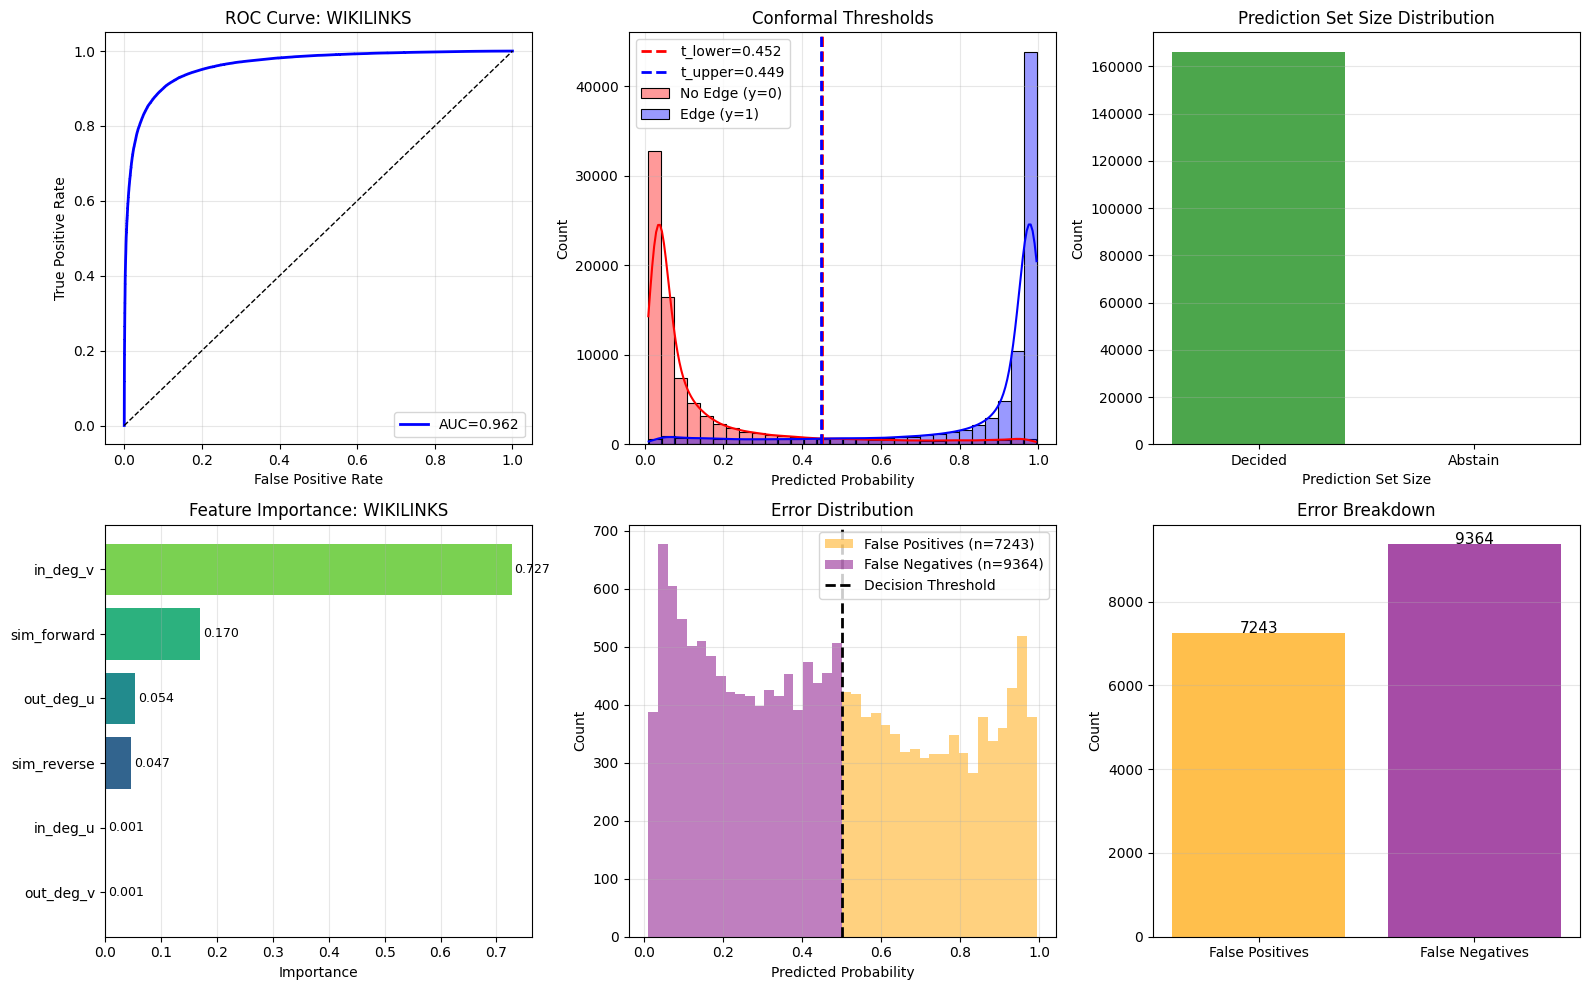


ANALYSIS SUMMARY
Feature Importance: {'out_deg_u': 0.054001992171671696, 'in_deg_v': 0.7269249288376066, 'in_deg_u': 0.0011767279009472584, 'out_deg_v': 0.0011418466231996076, 'sim_forward': 0.1699325753808145, 'sim_reverse': 0.04682192908576026}
Total False Positives: 7243
Total False Negatives: 9364


In [17]:
# Get node names for error analysis (if available)
node_names_sub = None
if 'names' in dataset:
    node_names_sub = dataset['names'][node_indices]

# Run the pipeline
results, analysis = run_directed_pipeline(
    adj=adj,
    name="WikiLinks",
    alpha=0.10,
    n_runs=10,  
    n_components=32,
    node_names=node_names_sub
)

print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)
print(f"Feature Importance: {analysis['feature_importance']}")
print(f"Total False Positives: {analysis['n_false_positives']}")
print(f"Total False Negatives: {analysis['n_false_negatives']}")

## 6. Results Summary

### Key Observations

1. **Feature Importance**: Check which features (degree-based vs embedding-based) contribute most to link prediction.

2. **Conformal Coverage**: Verify that the coverage is at least $1 - \alpha = 90\%$.

3. **Error Analysis**: Examine the top false positives and false negatives to understand model failures:
   - False Positives: Non-edges that look like edges (high similarity, high degree)
   - False Negatives: Real edges that don't fit the pattern (low similarity, low degree)

In [18]:
# Display final results table
print("\nResults across all runs:")
display(results)

print("\nMean and Std:")
display(results.describe().loc[['mean', 'std']])


Results across all runs:


,AUC,Base F1,Coverage,Abstention,Decided F1
0,0.961617,0.899881,0.901506,0.001443,0.901452
1,0.961495,0.899418,0.900917,0.001275,0.900735
2,0.960639,0.898664,0.899792,0.001209,0.899803
3,0.959892,0.896949,0.898144,0.001107,0.898162
4,0.960740,0.899073,0.901019,0.002346,0.900819
5,0.960640,0.897402,0.898577,0.001004,0.898495
6,0.960496,0.898500,0.899599,0.000710,0.899635
7,0.960693,0.898937,0.900520,0.001347,0.900145
8,0.961820,0.899312,0.901061,0.001239,0.900938
9,0.961660,0.898826,0.900562,0.000722,0.900390



Mean and Std:


,AUC,Base F1,Coverage,Abstention,Decided F1
mean,0.960969,0.898696,0.900170,0.00124,0.900057
std,0.000635,0.000900,0.001118,0.00046,0.001062
